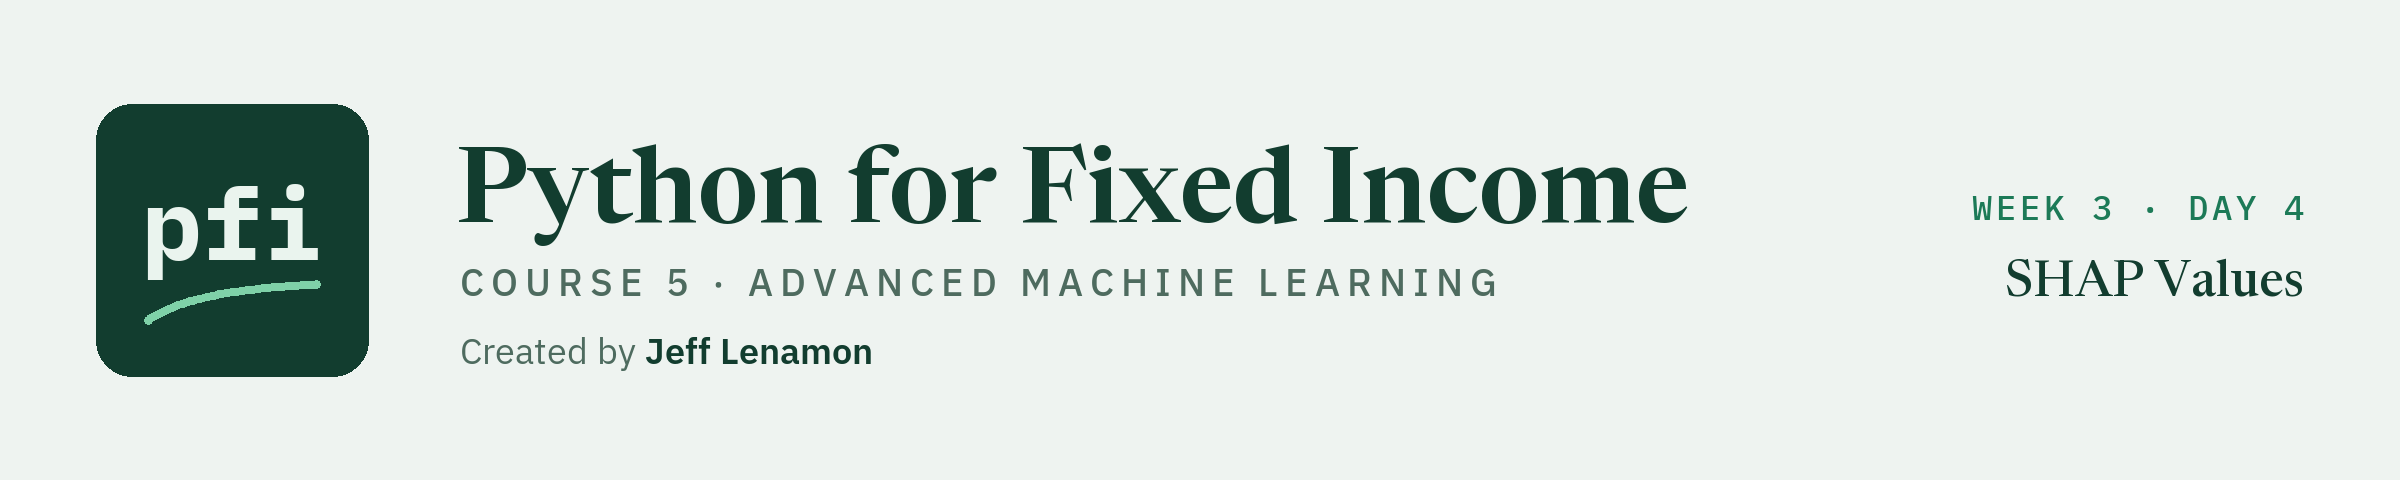

# SHAP Values

Week 3, Day 4. A SHAP value splits one company's model output across its 64 columns. Today: what the values add up to, how to read them for one company and for every company, how they compare with gain and split counts, and the words that keep them a description of the model.

**Data:** `polish_bankruptcy_5year.csv`, 5,910 financial statements of Polish companies: **real**, UCI Machine Learning Repository dataset 365, CC BY 4.0. Citation: Tomczak, S. (2016). Polish Companies Bankruptcy [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F600.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week3/day4/14_shap_values.ipynb)

Day 13 ended week 3's work on rare events. Today asks a different question of one fitted model: **for this company, how does the model's output split across the 64 ratios it was given?** A SHAP value answers that, one number per feature per company, and the numbers add up exactly to the model's output. That exactness is what makes them useful, and it is also why they are easy to over-read. A SHAP value describes the model. It says nothing about what would happen if a company changed a ratio, and nothing about why any company failed.

**The Polish rules, as on every week 3 day.**

* **The data is real.** `polish_bankruptcy_5year.csv` is the UCI file Course 4's capstone modelled: financial statements of Polish companies, each with 64 ratios (`Attr1` to `Attr64`) and a flag for bankruptcy after one year. The UCI page says the bankrupt companies were analysed from 2000 to 2012 and the others from 2007 to 2013. Nothing here describes companies in any other market or period.
* **Course 4's split, rebuilt.** `ensemblekit.course4_polish_rows` (day 11) drops the exact duplicate rows and rebuilds Course 4's 80/20 split: 4,680 training rows, 326 of them bankrupt (6.97 percent). Course 4's 1,170 test rows stay closed, by the test-row rule stated on day 1.
* **Names.** The course reads `Attr`k as the page's Xk, as Course 4 did, and gives both: `Attr27` (X27, profit on operating activities / financial expenses).
* **A model's output is described, never acted on.** The model's output is the model probability of bankruptcy in this file. A SHAP value is the feature's contribution to this row's log-odds, relative to the model's average log-odds. No output is a credit view on any company, and no SHAP value is a cause.

Today you will:

1. Fit one LightGBM model and split one company's output across its 64 columns.
2. Turn log-odds into a probability, and see why the contributions do not add in probability.
3. Draw a waterfall for one company and a beeswarm for every company.
4. Rank features by mean absolute SHAP value with `shap_table`, beside gain and split counts.
5. Plot the model's contributions against one ratio, and describe what the plot shows.
6. See what two columns that carry the same information do to SHAP values.
7. Meet XGBoost's SHAP values in float32, once.
8. Check a written description with `assert_described`.

Q. Set up today's work folder: the thread settings, the seed, the course data, and the modules.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# SHAP is slow to import, so only the days that use it import it here
import shap

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_14_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv", "polish_bankruptcy_5year.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_14_29kbj3rd, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv, polish_bankruptcy_5year.csv
SEED = 42


* From today the setup cell also runs `import shap`. SHAP is slow to import, so only the days that use it import it here.
* The day's tests read the card, benchmark, ratings, and Polish files, so all four are copied.

Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])


from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict


def base_models() -> dict:
    return {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            "tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)}


def test_stack_inputs_match_cross_val_predict():
    X, y = card_small()
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    for name, model in base_models().items():
        direct = cross_val_predict(model, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
        assert inputs[name].to_numpy() == pytest.approx(direct[:, 1], abs=1e-12)


def test_stack_inputs_columns_named():
    X, y = card_small(1_000)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    assert list(inputs.columns) == ["logistic", "tree"]
    assert inputs.index.equals(X.index)
    with pytest.raises(ValueError):
        ensemblekit.stack_inputs({}, X, y)


def test_stacking_classifier_uses_out_of_fold():
    X, y = card_small()
    stack = StackingClassifier(list(base_models().items()), final_estimator=LogisticRegression(),
                               stack_method="predict_proba", cv=ensemblekit.mlkit.cv_folds(), n_jobs=1).fit(X, y)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    by_hand = LogisticRegression().fit(inputs.to_numpy(), y)
    assert stack.final_estimator_.coef_ == pytest.approx(by_hand.coef_, abs=1e-10)
    assert stack.final_estimator_.intercept_ == pytest.approx(by_hand.intercept_, abs=1e-10)


def validation_scores(n: int = 2_000) -> tuple[pd.Series, np.ndarray]:
    """Outcomes and probabilities of a depth-3 tree, fitted on 3,000 training rows, on n validation rows."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X, y)
    return y_valid.iloc[:n], tree.predict_proba(X_valid.iloc[:n])[:, 1]


def test_bootstrap_interval_contains_point():
    y, proba = validation_scores()
    lower, upper = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=200)
    assert lower < roc_auc_score(y, proba) < upper
    assert upper - lower < 0.1


def test_bootstrap_interval_seeded():
    y, proba = validation_scores(500)
    first = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first == ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first != ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=7)


def test_bootstrap_interval_redraws_one_class_resample():
    # one positive in five rows: about a third of the resamples hold no positive and must be drawn again
    y, proba = np.array([0, 0, 0, 0, 1]), np.array([0.1, 0.2, 0.3, 0.4, 0.9])

    def strict_auc(actual, scores):
        assert len(np.unique(actual)) == 2, "a resample with one class reached the metric"
        return roc_auc_score(actual, scores)

    lower, upper = ensemblekit.bootstrap_interval(y, proba, strict_auc, n_boot=50)
    assert lower == upper == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_interval(np.zeros(5), proba, roc_auc_score)


from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


@cache
def polish_rows() -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish file."""
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    return ensemblekit.course4_polish_rows(frame)


def small_search() -> RandomizedSearchCV:
    return RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED),
                              {"max_depth": randint(2, 6), "min_samples_leaf": randint(5, 50)}, n_iter=4,
                              scoring="average_precision", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                              random_state=SEED, n_jobs=1)


def test_course4_polish_rows_counts_and_closed():
    X_train, y_train = polish_rows()
    assert (len(X_train), int(y_train.sum())) == (4_680, 326)
    assert list(X_train.columns) == [f"Attr{k}" for k in range(1, 65)]
    # Course 4's test rows, recomputed with Course 4's capstone code
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    unique = frame.drop_duplicates()
    _, X_test = train_test_split(unique, test_size=0.2, stratify=unique["class"], random_state=SEED)
    assert len(X_test) == 1_170
    assert not set(X_test.index) & set(X_train.index)
    with pytest.raises(ValueError):
        ensemblekit.course4_polish_rows(frame.iloc[:100])


def test_nested_score_one_per_fold():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    assert list(scores.index) == [f"fold_{i}" for i in range(1, 6)]
    assert ((scores > 0) & (scores < 1)).all()
    with pytest.raises(ValueError):
        ensemblekit.nested_score(RandomizedSearchCV(DecisionTreeClassifier(), {"max_depth": [2, 3]}, cv=None), X, y)


def test_nested_score_differs_from_best_score():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    search = small_search().set_params(cv=ensemblekit.mlkit.cv_folds()).fit(X, y)
    assert scores.mean() != pytest.approx(search.best_score_, abs=1e-6)


def test_search_table_sorted_and_columns():
    X, y = card_small()
    search = small_search().fit(X, y)
    table = ensemblekit.search_table(search, top=3)
    assert list(table.columns) == ["rank", "mean", "sd", "max_depth", "min_samples_leaf"]
    assert len(table) == 3
    assert table["rank"].is_monotonic_increasing
    assert table["mean"].iloc[0] == pytest.approx(search.best_score_, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.search_table(small_search())


from sklearn.model_selection import cross_validate


def test_safe_ratio_zero_and_missing():
    numerator = pd.Series([1.0, 2.0, np.nan, 4.0, 0.0])
    denominator = pd.Series([2.0, 0.0, 1.0, np.nan, 5.0])
    ratio = ensemblekit.safe_ratio(numerator, denominator)
    assert ratio.iloc[0] == pytest.approx(0.5, abs=1e-12)
    assert ratio.iloc[4] == pytest.approx(0.0, abs=1e-12)
    assert ratio.iloc[1:4].isna().all()
    with pytest.raises(ValueError):
        ensemblekit.safe_ratio(numerator, denominator.iloc[:3])


def test_safe_ratio_never_infinite():
    X_train, _ = polish_rows()
    # X2 total liabilities / total assets and X10 equity / total assets: debt to equity = X2 / X10
    ratio = ensemblekit.safe_ratio(X_train["Attr2"], X_train["Attr10"])
    assert not np.isinf(ratio).any()
    assert ratio.isna().sum() >= ((X_train["Attr10"] == 0) | X_train["Attr10"].isna() | X_train["Attr2"].isna()).sum()


def test_clip_bounds_from_training_rows():
    X, y = card_small()
    pipeline = Pipeline([("clip", ensemblekit.ClipToTraining()),
                         ("model", DecisionTreeClassifier(max_depth=2, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_estimator=True, return_indices=True)
    # each fold's bounds are that fold's training rows' quantiles, never the whole set's
    for fitted, train_rows in zip(result["estimator"], result["indices"]["train"]):
        clip = fitted.named_steps["clip"]
        assert clip.lower_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.01, axis=0), abs=1e-12)
        assert clip.upper_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.99, axis=0), abs=1e-12)
    clipped = ensemblekit.ClipToTraining().fit(X).transform(X)
    assert (clipped >= np.nanquantile(X, 0.01, axis=0)).all()


def test_clip_feature_names_out():
    X, _ = card_small(500)
    clip = ensemblekit.ClipToTraining().fit(X)
    assert list(clip.get_feature_names_out()) == list(X.columns)
    with pytest.raises(ValueError):
        ensemblekit.ClipToTraining(lower=0.9, upper=0.1).fit(X)


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


def test_class_counts_after_smote_balances():
    X, y = card_small(1_000)
    counts = ensemblekit.class_counts_after(SMOTE(random_state=SEED), X, y)
    assert list(counts.index) == [0, 1]
    assert counts[0] == counts[1] == int((y == 0).sum())


def test_prior_correction_hand():
    # a score of 0.5 from a model fitted at 50 percent, moved to 20 percent: odds 1 times k = 0.25, so 0.2
    assert ensemblekit.prior_correction([0.5], 0.5, 0.2) == pytest.approx([0.2], abs=1e-12)
    # 0.8 has odds 4; times 0.25 gives odds 1, so 0.5
    assert ensemblekit.prior_correction(np.array([0.8, 0.0, 1.0]), 0.5, 0.2) == pytest.approx([0.5, 0.0, 1.0], abs=1e-12)
    for bad in (0.0, 1.0, 1.5):
        with pytest.raises(ValueError):
            ensemblekit.prior_correction([0.5], bad, 0.2)


def test_prior_correction_identity_when_rates_equal():
    scores = np.linspace(0, 1, 11)
    assert ensemblekit.prior_correction(scores, 0.07, 0.07) == pytest.approx(scores, abs=1e-12)


def test_smote_inside_pipeline_scores_original_rows():
    X, y = card_small()
    pipeline = ImbPipeline([("smote", SMOTE(random_state=SEED)),
                            ("model", DecisionTreeClassifier(max_depth=3, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_indices=True)
    held_out = result["indices"]["test"]
    # every held-out row is an original row, each scored once: the folds' sizes add up to the rows given
    assert sum(len(rows) for rows in held_out) == len(X)
    assert sorted(np.concatenate(held_out).tolist()) == list(range(len(X)))
    proba = cross_val_predict(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
    assert proba.shape == (len(X), 2)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp', 'early_stopping_rows', 'scale_pos_weight', 'stack_inputs', 'bootstrap_interval', 'course4_polish_rows', 'nested_score', 'search_table', 'safe_ratio', 'ClipToTraining', 'class_counts_after', 'prior_correction']


Q. Load the Polish file and take Course 4's training rows.

In [6]:
# the 5,910 Polish statements (real data, CC BY 4.0; the citation is under the title), read so every number
# comes back bit for bit as written
frame = pd.read_csv("polish_bankruptcy_5year.csv", float_precision="round_trip")
# Course 4's training rows: duplicates dropped, its 80/20 split rebuilt, the test rows never returned
X_train, y_train = ensemblekit.course4_polish_rows(frame)

print(f"training rows: {len(X_train):,}, bankrupt {int(y_train.sum())} ({y_train.mean():.2%})")
print(f"features: {X_train.shape[1]}, of which {int(X_train.isna().any().sum())} have missing values")

training rows: 4,680, bankrupt 326 (6.97%)
features: 64, of which 48 have missing values


* 4,680 rows, 326 bankrupt, 64 ratios. 48 of the columns have missing values; LightGBM and XGBoost handle them natively, so today needs no imputer and no pipeline.

## 14.1 One Company's Output, Split Across 64 Columns

A SHAP value describes a fitted model, so first the model: LightGBM with 300 trees, a learning rate of 0.05, and at most 15 leaves per tree, fitted on all the training rows. No setting is chosen today, and no row is scored for a metric.

Q. Fit the model.

In [7]:
from lightgbm import LGBMClassifier

# 300 small trees, fitted on all 4,680 training rows; missing values go down a branch each tree learns
model = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=SEED, n_jobs=1, verbose=-1)
model.fit(X_train, y_train)
print(f"fitted: {model.n_estimators} trees on {len(X_train):,} rows and {model.n_features_in_} features")

fitted: 300 trees on 4,680 rows and 64 features


**Rows.** The model in this notebook is fitted on Course 4's 4,680 Polish training rows and described on those same rows; no row is scored for a metric today, and Course 4's 1,170 test rows are never scored in this course.

Q. Compute the SHAP values of every training row, and the model's raw output.

In [8]:
# TreeExplainer reads the trees themselves: exact values, no sampling, the same numbers every run
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
# the model's raw output: log-odds, before the logistic curve turns them into a probability
raw = model.predict(X_train, raw_score=True)

print(f"SHAP values: {shap_values.values.shape[0]:,} rows by {shap_values.values.shape[1]} features")
print(f"base value: {shap_values.base_values[0]:.4f} log-odds")
print(f"average of the model's log-odds over the {len(X_train):,} rows: {raw.mean():.4f}")
print(f"equal within 1e-9: {abs(shap_values.base_values[0] - raw.mean()) < 1e-9}")

SHAP values: 4,680 rows by 64 features
base value: -6.4588 log-odds
average of the model's log-odds over the 4,680 rows: -6.4588
equal within 1e-9: True


* One SHAP value per company per feature: a 4,680 by 64 table.
* The **base value** is where every company starts: -6.4588 log-odds, the average of the model's log-odds over the rows the trees were fitted on. Each company's SHAP values then say how far, and in which direction, each of its features moves the model's output away from that average.

Q. Take the first bankrupt company among the training rows. Which features move its output most, and do its 64 values add up?

In [9]:
# the first bankrupt company by position among the training rows
row = int(np.flatnonzero(y_train.to_numpy() == 1)[0])
row_values = pd.Series(shap_values.values[row], index=X_train.columns)

# its six largest contributions in size, beside the company's own value of each ratio
order = row_values.abs().sort_values(ascending=False, kind="stable").index[:6]
print(pd.DataFrame({"value": X_train.iloc[row][order], "SHAP value": row_values[order]}).round(4).to_string())
print()
print(f"row {row} (file label {X_train.index[row]}): base value {shap_values.base_values[row]:.4f} + sum of 64 SHAP values "
      f"{row_values.sum():.4f} = {shap_values.base_values[row] + row_values.sum():.4f}")
print(f"the model's log-odds for this row: {raw[row]:.4f}; equal within 1e-9: "
      f"{abs(shap_values.base_values[row] + row_values.sum() - raw[row]) < 1e-9}")

         value  SHAP value
Attr46  0.0420      2.1918
Attr27 -1.7329      0.9643
Attr38 -1.0383      0.9080
Attr35 -0.0926      0.7560
Attr39 -0.0902      0.6471
Attr58  1.1163     -0.6351

row 13 (file label 5545): base value -6.4588 + sum of 64 SHAP values 8.6317 = 2.1729
the model's log-odds for this row: 2.1729; equal within 1e-9: True


* This company's model output is 2.1729 log-odds, far above the base value of -6.4588. The 64 SHAP values add up to the difference, 8.6317, exactly: base value plus the row's values equals the model's log-odds.
* The largest contribution is `Attr46` (X46, (current assets - inventory) / short-term liabilities), 2.1918, then `Attr27` (X27, profit on operating activities / financial expenses) and `Attr38` (X38, constant capital / total assets). 42 of the 64 values are positive (toward a higher score), 20 negative, and 2 exactly zero (features the trees never used on this company's path, or never used at all). The largest negative one is `Attr58`, -0.6351.
* Each number is a SHAP value: the feature's contribution to this row's log-odds, relative to the model's average log-odds. It describes how this model's output for this company splits across features. It is not the effect of changing the ratio, and not a reason this company failed.

Q. Add two functions to `ensemblekit.py`: `shap_table`, which section 14.5 uses, and `assert_additive`, which turns the check you just did into a function for every row. The word list at the top is for section 14.9.

In [10]:
%%writefile -a ensemblekit.py


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")

Appending to ensemblekit.py


* `assert_additive` takes the model's raw output, in log-odds, and stops if any row's base value plus SHAP values misses it by more than `tol`, naming the worst row. Its message says the likely mistake: a probability passed where log-odds belong.

Q. Add the tests: the table is sorted, LightGBM's values add up to 1e-9, and probabilities in place of log-odds are refused.

In [11]:
%%writefile -a test_ensemblekit.py


import warnings

with warnings.catch_warnings():
    # shap 0.52 calls three matplotlib colormap methods that matplotlib marks for a later deprecation. pytest shows
    # PendingDeprecationWarning (a notebook kernel does not), so the import is quietened here, for shap only.
    warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="shap")
    import shap
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


@cache
def lightgbm_shap() -> tuple[LGBMClassifier, pd.DataFrame, shap.Explanation]:
    """A 30-tree LightGBM fitted on the Polish training rows (missing values handled natively), and its SHAP
    values on the first 500 of them."""
    X, y = polish_rows()
    model = LGBMClassifier(n_estimators=30, random_state=SEED, n_jobs=1, verbose=-1).fit(X, y)
    rows = X.iloc[:500]
    return model, rows, shap.TreeExplainer(model)(rows)


def test_shap_table_sorted():
    _, rows, values = lightgbm_shap()
    table = ensemblekit.shap_table(values)
    assert list(table.columns) == ["mean_abs_shap", "rank"]
    assert set(table.index) == set(rows.columns)
    assert table["mean_abs_shap"].is_monotonic_decreasing
    assert table["rank"].tolist() == list(range(1, 65))
    assert table["mean_abs_shap"].iloc[0] == pytest.approx(np.abs(values.values).mean(axis=0).max(), abs=1e-12)
    assert len(ensemblekit.shap_table(values, top=5)) == 5


def test_assert_additive_lightgbm():
    model, rows, values = lightgbm_shap()
    ensemblekit.assert_additive(values, model.predict(rows, raw_score=True), tol=1e-9)


def test_assert_additive_raises_on_probability():
    model, rows, values = lightgbm_shap()
    with pytest.raises(AssertionError, match="largest gap"):
        ensemblekit.assert_additive(values, model.predict_proba(rows)[:, 1])
    # the log-odds sum becomes the model's probability through the logistic function
    total = values.base_values + values.values.sum(axis=1)
    assert ensemblekit.mlkit.logistic_probability(total) == pytest.approx(model.predict_proba(rows)[:, 1], abs=1e-9)

Appending to test_ensemblekit.py


* The test file imports `shap` inside `warnings.catch_warnings()`: pytest shows a pending deprecation warning from inside shap that a notebook does not, and the test run must stay clean. The fixture fits a 30-tree model and computes SHAP values on 500 rows, so the tests stay fast.

Q. Reload the module, run the tests, and check every row of today's model.

In [12]:
importlib.reload(ensemblekit)
print(f"shap_table and assert_additive in ensemblekit: {hasattr(ensemblekit, 'shap_table') and hasattr(ensemblekit, 'assert_additive')}")

shap_table and assert_additive in ensemblekit: True


In [13]:
import re

# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

.....................................................                    [100%]
53 passed in 118.70s



In [14]:
# stops with the largest gap if any of the 4,680 rows does not add up
ensemblekit.assert_additive(shap_values, raw, tol=1e-9)
gaps = np.abs(shap_values.base_values + shap_values.values.sum(axis=1) - raw)
print(f"every row adds up: within 1e-9 {bool((gaps < 1e-9).all())}, within 1e-12 {bool((gaps < 1e-12).all())}")

every row adds up: within 1e-9 True, within 1e-12 True


* `53 passed`: day 13's 50 and today's 3.
* All 4,680 rows add up within 1e-12. LightGBM computes in 64-bit floats, so the only gap is the last digits of adding 64 numbers.

## 14.2 From Log-Odds to Probability

Course 4 day 6 turned log-odds into a probability with the logistic curve, `mlkit.logistic_probability`. A tree booster's raw output is log-odds too.

Q. Turn this company's log-odds, and the base value, into probabilities.

In [15]:
# the logistic curve, 1 / (1 + exp(-z)), from Course 4's module
print(f"this company: {raw[row]:.4f} log-odds -> {mlkit.logistic_probability(raw[row]):.4f}; "
      f"predict_proba gives {model.predict_proba(X_train.iloc[[row]])[0, 1]:.4f}")
print(f"base value: {shap_values.base_values[row]:.4f} log-odds -> {mlkit.logistic_probability(shap_values.base_values[row]):.4f}")
proba_train = model.predict_proba(X_train)[:, 1]
print(f"average model probability over the rows: {proba_train.mean():.4f}; bankrupt share: {y_train.mean():.4f}")

this company: 2.1729 log-odds -> 0.8978; predict_proba gives 0.8978
base value: -6.4588 log-odds -> 0.0016


average model probability over the rows: 0.0697; bankrupt share: 0.0697


* The company's 2.1729 log-odds is a model probability of bankruptcy in this file of 0.8978, as `predict_proba` says.
* The base value as a probability is 0.0016, far below the average probability of 0.0697 (which is close to the bankrupt share, 0.0697). The logistic curve is not a straight line: the average of the log-odds, turned into a probability, is not the average probability. Most companies sit at very low log-odds and a few far above, and the curve treats those two sides very differently.

Q. The company's largest contribution is `Attr46`. How much probability does it add?

In [16]:
c = row_values["Attr46"]
base = shap_values.base_values[row]
# the same contribution, added at two different starting points on the logistic curve
from_base = mlkit.logistic_probability(base + c) - mlkit.logistic_probability(base)
at_this_row = mlkit.logistic_probability(raw[row]) - mlkit.logistic_probability(raw[row] - c)
print(f"Attr46: {c:.4f} log-odds")
print(f"added to the base value it moves the probability by {100 * from_base:.2f} percentage points")
print(f"taken away from this company's total it moves the probability by {100 * at_this_row:.2f} percentage points")

Attr46: 2.1918 log-odds
added to the base value it moves the probability by 1.23 percentage points
taken away from this company's total it moves the probability by 40.25 percentage points


* The same 2.1918 log-odds is worth 1.23 percentage points of probability when added to the base value, and 40.25 points at this company's total. **SHAP values add up in log-odds, not in probability.** There is no honest way to say "`Attr46` adds so many points of probability" for this company: the answer depends on where on the curve you start. Contributions are stated in log-odds, and only the total is turned into a probability.

## 14.3 A Waterfall for One Company

A waterfall draws one company's split: it starts at the base value, adds one contribution per bar, and ends at the model's log-odds.

Q. Draw the waterfall for the same company.

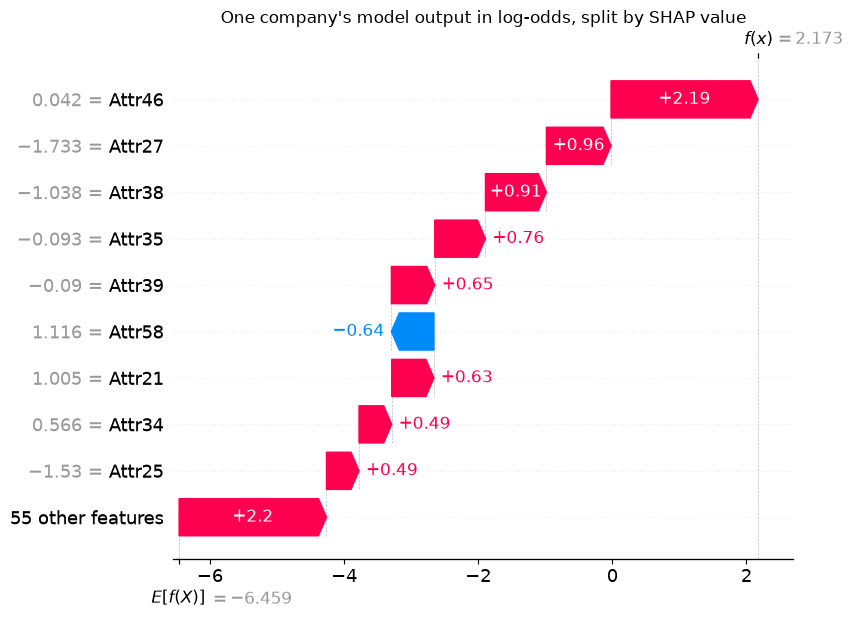

In [17]:
import matplotlib.pyplot as plt

# one company: base value at the bottom, one bar per feature, the model's log-odds at the top
shap.plots.waterfall(shap_values[row], max_display=10, show=False)
plt.title("One company's model output in log-odds, split by SHAP value")
plt.show()

* Read from the bottom: E[f(X)] is the base value, -6.4588; each bar adds one feature's SHAP value, red toward a higher score and blue toward a lower one, with the company's own value of the ratio beside the name; f(x) at the top is the model's log-odds, 2.1729. The smaller contributions are summed in one bar, "other features".
* The axis is in log-odds. The chart shows how the model's output for this company is built up; it does not show what would happen to the company if a ratio changed.

## 14.4 The Beeswarm: Every Company, Every Column

Q. Draw every company's SHAP values for the twelve features with the largest mean absolute value.

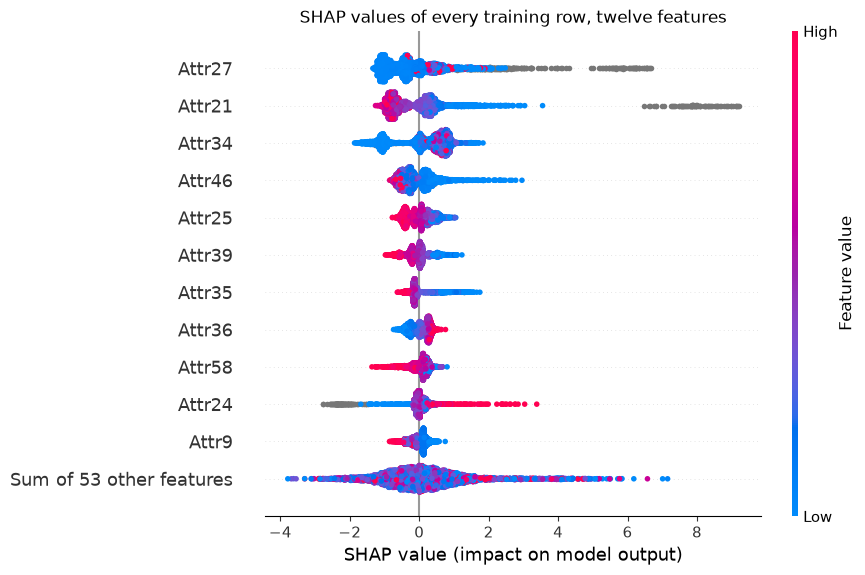

In [18]:
# one dot per company per feature: position is the SHAP value, colour is the company's value of the ratio
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP values of every training row, twelve features")
plt.show()

* Each row of dots is one feature, sorted by mean absolute SHAP value; each dot is one company. Its position is that company's SHAP value for the feature, its colour the company's value of the ratio (red high, blue low, grey missing).
* `Attr27`, `Attr21`, and `Attr34` come first. Where the dots stretch far to one side, a few companies get large contributions from that feature in that direction, while most sit near zero.
* The colours describe association in this file: which values of a ratio go with which contributions in this model. They are not the effect of the ratio.

> **STORY: a paper from May 2017.** On 22 May 2017 Scott Lundberg and Su-In Lee posted a paper to arXiv, number 1705.07874; the record's comment field reads "To appear in NIPS 2017", and the record was last updated on 25 November 2017. Its title describes a unified approach to interpreting the outputs of models, the job this notebook does with SHAP values. The title itself is left to the record, linked below, because it uses a word this course keeps for the `predict` method.
>
> Source (read 2026-10-05): the arXiv record of the paper, https://arxiv.org/abs/1705.07874, read through https://export.arxiv.org/api/query?id_list=1705.07874. Only the title, authors, dates, and comment field are taken from it; the paper itself was not read for this course, so nothing here says what it contains.

## 14.5 Mean Absolute SHAP Value, Gain, and Split Counts

A beeswarm is a picture; a table ranks. The usual one-number summary of a feature is its **mean absolute SHAP value**: the average size of its contribution over the rows, in log-odds. LightGBM has two summaries of its own: **gain**, the total improvement in the training loss from the splits on the feature, and **split counts**, how many times the trees split on it.

Q. Rank the features by mean absolute SHAP value with `shap_table`, and put LightGBM's two ranks beside it.

In [19]:
table = ensemblekit.shap_table(shap_values, top=10)
# LightGBM's own measures, from the fitted booster
gain = pd.Series(model.booster_.feature_importance("gain"), index=X_train.columns)
split = pd.Series(model.booster_.feature_importance("split"), index=X_train.columns)
table["gain_rank"] = gain.rank(ascending=False, method="min").astype(int)[table.index]
table["split_rank"] = split.rank(ascending=False, method="min").astype(int)[table.index]
print(table.round(4).to_string())
print()
print(f"top three by gain: {gain.sort_values(ascending=False, kind='stable').index[:3].tolist()}")
print(f"top three by split count: {split.sort_values(ascending=False, kind='stable').index[:3].tolist()}")

         mean_abs_shap  rank  gain_rank  split_rank
feature                                            
Attr27          0.7702     1          1           2
Attr21          0.7174     2          2           1
Attr34          0.6608     3          3           4
Attr46          0.3655     4          4           5
Attr25          0.2954     5          9          12
Attr39          0.2349     6         11          14
Attr35          0.2291     7          5          17
Attr36          0.2215     8         18          15
Attr58          0.2015     9         12           6
Attr24          0.1847    10          6           3

top three by gain: ['Attr27', 'Attr21', 'Attr34']
top three by split count: ['Attr21', 'Attr27', 'Attr24']


* By mean absolute SHAP value the model leans most on `Attr27` (X27, profit on operating activities / financial expenses), `Attr21` (X21, sales (n) / sales (n-1)), and `Attr34` (X34, operating expenses / total liabilities). They are also the top three by gain, in the same order.
* Split counts rank differently: their top three are `Attr21`, `Attr27`, and `Attr24`, which includes `Attr24` (rank 10 by SHAP). A split count says how often the trees asked about a feature, not how much the answers moved the output: many small splits can count more than a few that matter.
* All three measures describe this fitted model: which features it leans on, an association in this file. None of them is a cause, and none is a ranking of what makes a company fail.

## 14.6 A Dependence Plot, Described

A dependence plot is one feature's column of the beeswarm, spread out: the model's contributions plotted against the feature's values, one dot per company. Today's feature is `Attr27` (X27, profit on operating activities / financial expenses). Its values run from large negative numbers to very large positive ones, so the plot is cut at the 1st and 99th percentiles of the column.

Q. Plot the SHAP values of `Attr27` against its values.

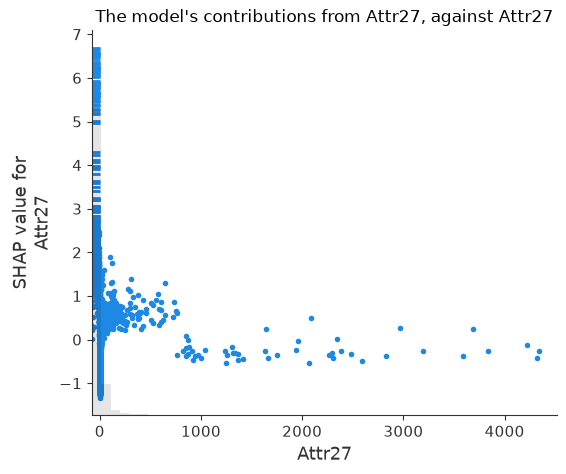

In [20]:
# x: each company's Attr27; y: its SHAP value for Attr27; the axis cut at the column's 1st and 99th percentiles
shap.plots.scatter(shap_values[:, "Attr27"], xmin="percentile(1)", xmax="percentile(99)", show=False)
plt.title("The model's contributions from Attr27, against Attr27")
plt.show()

Q. Put numbers on the picture: by band of `Attr27`, how many companies, what share went bankrupt, and what is the average SHAP value?

In [21]:
attr27 = X_train["Attr27"]
shap27 = shap_values[:, "Attr27"].values
bands = {"missing": attr27.isna(), "0 or below": attr27 <= 0, "above 0, up to 1": (attr27 > 0) & (attr27 <= 1),
         "above 1": attr27 > 1}
summary = pd.DataFrame({
    "companies": {name: int(mask.sum()) for name, mask in bands.items()},
    "bankrupt share": {name: y_train[mask].mean() for name, mask in bands.items()},
    "average SHAP value": {name: shap27[mask.to_numpy()].mean() for name, mask in bands.items()},
})
print(summary.round(4).to_string())

                  companies  bankrupt share  average SHAP value
missing                 317          0.2965              2.9087
0 or below              974          0.1468             -0.0037
above 0, up to 1       1225          0.0114             -0.9508
above 1                2164          0.0347             -0.0862


* Companies with `Attr27` **missing** (317 of them) get by far the largest contributions toward a higher score, 2.9087 log-odds on average, and 29.7 percent of them went bankrupt. The trees learned a branch for missing values, and the model leans on it. The page does not say why a value is missing.
* Companies with `Attr27` above 0 and up to 1 get the most negative average contribution, -0.9508, and the lowest bankrupt share, 1.1 percent. The four bands rank the same way by bankrupt share and by average contribution.
* Companies at 0 or below get an average contribution near zero, -0.0037, although 14.7 percent of them went bankrupt, more than twice the file's 7.0 percent. A contribution near zero does not mean the band looks ordinary to the model: it means `Attr27` moves those companies' output little from the model's average, and whatever separates them sits in other columns' contributions. A SHAP value is one feature's part of a model that sees all 64 columns at once.
* This is the model's contributions plotted against the feature's values, an association in this file. It is not the effect of changing `Attr27`, and the plot cannot say what would happen to a company that raised its interest cover.

## 14.7 Two Columns That Carry the Same Information

Course 4's capstone found that the page defines X2 as total liabilities / total assets and X17 as total assets / total liabilities: one is the reciprocal of the other, and the file agrees. Two columns that order the companies the same way give the trees two ways to ask one question.

Q. How closely do `Attr2` and `Attr17` agree, and how does the model share its SHAP values between them?

In [22]:
both = X_train[["Attr2", "Attr17"]].dropna()
reciprocal = np.isclose(both["Attr17"], 1 / both["Attr2"], rtol=1e-2, atol=1e-4)
print(f"rows with both: {len(both):,}; Attr17 = 1 / Attr2 within 1 percent: {int(reciprocal.sum()):,}")
print(f"Spearman correlation of Attr2 and Attr17: {X_train['Attr2'].corr(X_train['Attr17'], method='spearman'):.4f}")
full_table = ensemblekit.shap_table(shap_values)
print(full_table.loc[["Attr2", "Attr17"]].round(4).to_string())

rows with both: 4,666; Attr17 = 1 / Attr2 within 1 percent: 4,665
Spearman correlation of Attr2 and Attr17: -0.9986
         mean_abs_shap  rank
feature                     
Attr2           0.0108    60
Attr17          0.1183    22


* On 4,665 of 4,666 rows `Attr17` is 1 / `Attr2` within 1 percent, and their rank correlation is -0.9986: the same ordering of companies, reversed.
* The model gives `Attr17` a mean absolute SHAP value of 0.1183 (rank 22) and `Attr2` only 0.0108 (rank 60). The trees happened to split mostly on one of the pair, and SHAP gives the credit to the column the trees used. A small SHAP value does not mean the information in a column is absent from the model: it may sit in a twin.

Q. Refit the same model without `Attr17`. Where does its share go?

In [23]:
# the same settings, one column fewer
X_no17 = X_train.drop(columns="Attr17")
model_no17 = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=SEED, n_jobs=1, verbose=-1)
model_no17.fit(X_no17, y_train)
table_no17 = ensemblekit.shap_table(shap.TreeExplainer(model_no17)(X_no17))

# the change in each remaining feature's mean absolute SHAP value
change = (table_no17["mean_abs_shap"] - full_table["mean_abs_shap"].drop("Attr17")).sort_values(ascending=False, kind="stable")
print(f"Attr2 without Attr17: {table_no17.loc['Attr2', 'mean_abs_shap']:.4f} (rank {table_no17.loc['Attr2', 'rank']})")
print("largest rises:")
print(change.head(3).round(4).to_string())
print(f"top three without Attr17: {table_no17.index[:3].tolist()}")

Attr2 without Attr17: 0.0130 (rank 58)
largest rises:
feature
Attr8     0.1088
Attr34    0.0701
Attr38    0.0451
top three without Attr17: ['Attr27', 'Attr34', 'Attr21']


* Without `Attr17`, `Attr2` rises only to 0.0130 (rank 58). The largest rises are `Attr8` (+0.1088), `Attr34` (+0.0701), `Attr38` (+0.0451): the share `Attr17` had does not move to its twin alone; it spreads over other columns. The top three stay `Attr27`, `Attr34`, and `Attr21`.
* So a SHAP ranking is a description of one fitted model with one set of columns. Drop or add a correlated column and the credit moves, while the model's outputs barely change.

## 14.8 XGBoost's SHAP Values, in float32

`TreeExplainer` works on XGBoost too, with one difference worth seeing once: XGBoost stores its trees in 32-bit floats.

Q. Fit XGBoost (100 trees, depth 3) on the same rows, compute its SHAP values, and check they add up to its log-odds.

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, max_depth=3, random_state=SEED, n_jobs=1)
xgb_model.fit(X_train, y_train)
xgb_values = shap.TreeExplainer(xgb_model)(X_train)
# XGBoost's log-odds: output_margin=True
xgb_margin = xgb_model.predict(X_train, output_margin=True)
xgb_gaps = np.abs(xgb_values.base_values + xgb_values.values.astype(float).sum(axis=1) - xgb_margin)

print(f"SHAP values stored as {xgb_values.values.dtype}")
print(f"every row adds up: within 1e-9 {bool((xgb_gaps < 1e-9).all())}, within 1e-5 {bool((xgb_gaps < 1e-5).all())}")
ensemblekit.assert_additive(xgb_values, xgb_margin, tol=1e-5)
print(f"top three by mean absolute SHAP value: {ensemblekit.shap_table(xgb_values).index[:3].tolist()}")

SHAP values stored as float32
every row adds up: within 1e-9 False, within 1e-5 True
top three by mean absolute SHAP value: ['Attr27', 'Attr21', 'Attr46']


* XGBoost's SHAP values come back as `float32`, and they add up to its log-odds within 1e-5 but not within 1e-9: 32-bit floats carry about seven significant digits. That is why `assert_additive` takes a tolerance, 1e-9 for LightGBM and 1e-5 for XGBoost, and why the course prints no XGBoost output beyond 4 decimals.
* Its top three by mean absolute SHAP value are `Attr27`, `Attr21`, and `Attr46`, 2 of them among LightGBM's top three. Another model, fitted on the same rows, is described by its own SHAP values.

Q. Add the XGBoost test and run the tests.

In [25]:
%%writefile -a test_ensemblekit.py


def test_assert_additive_xgboost_float32():
    X, y = polish_rows()
    model = XGBClassifier(n_estimators=30, max_depth=3, random_state=SEED, n_jobs=1).fit(X, y)
    rows = X.iloc[:500]
    values = shap.TreeExplainer(model)(rows)
    # XGBoost computes in float32: the sum agrees to about 1e-6, not 1e-12
    ensemblekit.assert_additive(values, model.predict(rows, output_margin=True), tol=1e-5)

Appending to test_ensemblekit.py


In [26]:
import re

# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

......................................................                   [100%]
54 passed in 135.41s



* `54 passed`.

## 14.9 The Words

A SHAP value is exact arithmetic about a model, and that exactness makes it tempting to write about it as if it were a finding about companies. The course's rule: describe what the model leans on, in this file. Course 4's `mlkit.assert_descriptive` already stops words about the future; today's `assert_described` adds a short list of words that claim a reason.

Q. Add `assert_described` and its tests.

In [27]:
%%writefile -a ensemblekit.py


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Appending to ensemblekit.py


In [28]:
%%writefile -a test_ensemblekit.py


def test_assert_described_passes_plain_text():
    ensemblekit.assert_described("The model leans on Attr27 and Attr21 in this file; association, not a finding about the world.")


def test_assert_described_names_the_word():
    with pytest.raises(ValueError, match="because"):
        ensemblekit.assert_described("Companies failed because their ratio was low.")
    with pytest.raises(ValueError, match="driver"):
        ensemblekit.assert_described("Attr27 is the main driver of the score.")
    # a forecast word is caught by mlkit.assert_descriptive first
    with pytest.raises(ValueError, match="forecast"):
        ensemblekit.assert_described("The model will flag more companies next year.")

Appending to test_ensemblekit.py


In [29]:
importlib.reload(ensemblekit)
print(f"words assert_described stops: {ensemblekit.EXPLANATION_WORDS}")

words assert_described stops: ['cause', 'causes', 'caused', 'driver', 'drivers', 'drives', 'reason', 'reasons', 'because']


In [30]:
import re

# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

........................................................                 [100%]
56 passed in 29.34s



* `56 passed`: today's three functions, with 6 tests.
* "because" is on the list so a writer looks again at every sentence that claims a reason. The docstring says the list is a reminder, not a proof: a sentence can claim a cause with none of these words.

Q. Check a description of today's model.

In [31]:
description = ("In Course 4's 4,680 Polish training rows, the LightGBM model leans most on Attr27, Attr21, and Attr34 by mean absolute SHAP value. Companies with Attr27 missing receive the largest contributions toward a higher score. This is an association in this file, described for this model.")
ensemblekit.assert_described(description)
print("passes assert_described:")
print(description)

passes assert_described:
In Course 4's 4,680 Polish training rows, the LightGBM model leans most on Attr27, Attr21, and Attr34 by mean absolute SHAP value. Companies with Attr27 missing receive the largest contributions toward a higher score. This is an association in this file, described for this model.


Q. And a sentence that reads the SHAP values as a reason. The cell catches the error the check raises and prints its message.

In [32]:
# the check raises ValueError naming the words; catch it here and print the message
try:
    ensemblekit.assert_described('Attr27 drives the score: companies with low interest cover failed because of it.')
except ValueError as error:
    print(f"stopped: {error}")

stopped: the text uses cause or explanation words: ['drives', 'because']


* The check stops and names the words it found. The sentence it refused claims more than any SHAP value can show: the values describe how this model splits its output, not why any company failed. Rewrite it as the description above does.

## Excel Side by Side

Excel has no function for SHAP values: they come from walking every tree of the model, which only the library does. What Excel can do is check what they add up to. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05), with this company's base value pasted into B1 and its 64 SHAP values into B2:B65, and the 4,680 SHAP values of `Attr27` into D2:D4681 of a second sheet.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The company's log-odds | `shap_values.base_values[row] + row_values.sum()` | `=B1+SUM(B2:B65)` | 2.1729 |
| Its probability | `mlkit.logistic_probability(raw[row])` | `=1/(1+EXP(-B66))` | 0.8978 |
| The base value as a probability | `mlkit.logistic_probability(base)` | `=1/(1+EXP(-B1))` | 0.0016 |
| Mean absolute SHAP value of `Attr27` | `ensemblekit.shap_table(shap_values)` | `=AVERAGE(ABS(D2:D4681))` | 0.7702 |

**The row adding up.** In B66, `=B1+SUM(B2:B65)` adds the base value and the 64 contributions: that is the model's log-odds for the company, the same job as the Python line that adds `base_values[row]` to `row_values.sum()`. In B67, `=1/(1+EXP(-B66))` is the logistic curve, `mlkit.logistic_probability`, and gives the model's probability. Never sum the contributions after turning each one into a probability: section 14.2 showed the same contribution is worth a different number of points depending on where it starts.

**The mean absolute value.** `=AVERAGE(ABS(D2:D4681))` takes the absolute value of every cell and averages them, the job `np.abs(values).mean(axis=0)` does inside `shap_table`. In Excel 365 it works as typed, a dynamic-array formula; it was typed here with `Formula2`, the dynamic-array route.

Q. Do Excel's numbers equal Python's?

In [33]:
# Excel's numbers, from the course's Excel check, beside Python's for the same company and column
excel = {"the company's log-odds": 2.1729190597550403,
         "its probability": 0.8977911371365429,
         "the base value as a probability": 0.0015642108137010383,
         "mean absolute SHAP value of Attr27": 0.7702123949107926}
python = {"the company's log-odds": shap_values.base_values[row] + row_values.sum(),
          "its probability": model.predict_proba(X_train.iloc[[row]])[0, 1],
          "the base value as a probability": mlkit.logistic_probability(shap_values.base_values[row]),
          "mean absolute SHAP value of Attr27": np.abs(shap_values[:, "Attr27"].values).mean()}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
side_by_side

,Excel,Python,within 1e-12
the company's log-odds,2.172919,2.172919,True
its probability,0.897791,0.897791,True
the base value as a probability,0.001564,0.001564,True
mean absolute SHAP value of Attr27,0.770212,0.770212,True


* Every number matches within 1e-12. Excel's sum and Python's add the same 65 numbers in a different order, so they agree to the last few digits, not bit for bit; the comparison prints "within 1e-12" rather than the gap.

## Save the Day with Git

Today's Git step is a tag: a name fixed to one commit, so the last teaching day of week 3 can be found again by name.

Q. Make the work folder a repository.

In [34]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [35]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_14_29kbj3rd and nowhere else


Q. Tell Git which files never to track, then commit Course 4's module and today's two files.

In [36]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [37]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "SHAP values: shap_table, assert_additive, assert_described, 56 tests"
!git -C "{work}" log --oneline

3c5bd2e SHAP values: shap_table, assert_additive, assert_described, 56 tests


Q. Log today's numbers: the ten features with the largest mean absolute SHAP value, with 4 decimals. No row was scored for a metric today, so the log is the SHAP table.

In [38]:
# the day's log: the model, then the shap_table rows, 4 decimals and LF line endings
log = ensemblekit.shap_table(shap_values, top=10).reset_index()
log.insert(0, "model", "lightgbm_300_trees")
log.to_csv("shap_table.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "shap_table.csv").read_text(encoding="utf-8"))

model,feature,mean_abs_shap,rank
lightgbm_300_trees,Attr27,0.7702,1
lightgbm_300_trees,Attr21,0.7174,2
lightgbm_300_trees,Attr34,0.6608,3
lightgbm_300_trees,Attr46,0.3655,4
lightgbm_300_trees,Attr25,0.2954,5
lightgbm_300_trees,Attr39,0.2349,6
lightgbm_300_trees,Attr35,0.2291,7
lightgbm_300_trees,Attr36,0.2215,8
lightgbm_300_trees,Attr58,0.2015,9
lightgbm_300_trees,Attr24,0.1847,10



In [39]:
!git -C "{work}" add shap_table.csv
!git -C "{work}" commit -q -m "Mean absolute SHAP values of the LightGBM model on Course 4's Polish training rows, top 10"
!git -C "{work}" tag week3-teaching
!git -C "{work}" log --oneline --decorate

6560ece (HEAD -> main, tag: week3-teaching) Mean absolute SHAP values of the LightGBM model on Course 4's Polish training rows, top 10
3c5bd2e SHAP values: shap_table, assert_additive, assert_described, 56 tests


* `git tag week3-teaching` names the last commit. `git log --oneline --decorate` shows the tag beside its commit, with `HEAD -> master` or `HEAD -> main` (whichever your Git names a new branch). Later, `git show week3-teaching` or `git diff week3-teaching` finds this commit by name, without a hash.

## Bring It Home

In your own `my_bondmath` folder, open a PowerShell terminal in VS Code. The Polish file is already there from day 11.

**Step 1.** Paste the code of today's two `%%writefile -a ensemblekit.py` cells (sections 14.1 and 14.9), without their first lines, at the end of `ensemblekit.py`, and today's three `%%writefile -a test_ensemblekit.py` cells (14.1, 14.8, 14.9) at the end of `test_ensemblekit.py`. Save both.

**Step 2.** Run the tests.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_ensemblekit.py
```

The last line says `56 passed`.

**Step 3.** Read the change, commit it, and tag the commit.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "SHAP values: shap_table, assert_additive, assert_described, 56 tests"
git tag week3-teaching
git log --oneline --decorate -3
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Compute SHAP values of a tree model with `shap.TreeExplainer`, and say what the base value is.
* Show that a row's SHAP values add up to the model's log-odds with `assert_additive`, and turn the total into a probability.
* Say why contributions are stated in log-odds and never as points of probability.
* Read a waterfall for one company and a beeswarm for every company.
* Rank features by mean absolute SHAP value with `shap_table`, and say why split counts rank differently.
* Describe a dependence plot as the model's contributions against a feature's values, never as an effect.
* Say what a correlated twin does to SHAP values.
* Check a description with `assert_described`, and tag a commit.

Tomorrow, the capstone: a file you have not seen, four models, and a description of the chosen one, with SHAP values.

## Exercises

The exercises use today's model on Course 4's 4,680 Polish training rows; Course 4's 1,170 test rows stay closed. Every answer describes this model in this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the training rows, fits today's model, computes its SHAP values, and defines `check`, a small function that marks your answers.

In [40]:
from lightgbm import LGBMClassifier

# Course 4's Polish training rows and today's model
frame = pd.read_csv("polish_bankruptcy_5year.csv", float_precision="round_trip")
X_train, y_train = ensemblekit.course4_polish_rows(frame)
model = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=SEED, n_jobs=1, verbose=-1)
model.fit(X_train, y_train)
shap_values = shap.TreeExplainer(model)(X_train)
# section 14.1's company: the first bankrupt row by position
row = int(np.flatnonzero(y_train.to_numpy() == 1)[0])


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Find the five training rows with the highest model probability of bankruptcy in this file (`np.argsort(..., kind="stable")`, highest first). For each, find the feature with the largest SHAP value in size. Store the five feature names, in that order, as a list in **ex1_top_features**.

In [41]:
ex1_top_features = ...

In [42]:
check("Exercise 1 the five largest contributions", ex1_top_features, ['Attr21', 'Attr21', 'Attr21', 'Attr21', 'Attr21'])

Exercise 1 the five largest contributions: not attempted yet


### Exercise 2

Q. Permutation importance needs rows the model was not fitted on. Take the first fold of `mlkit.cv_folds()` on the training rows (`next(mlkit.cv_folds().split(X_train, y_train))` gives the fitting and held-out positions), fit today's model settings on the fitting part, and run `ensemblekit.importance_table` on the held-out part with `scoring="average_precision"`, `n_repeats=5`, `seed=SEED`. How many of its top 10 features by permutation importance are also in today's top 10 by mean absolute SHAP value? Store the count in **ex2_overlap**.

In [43]:
ex2_overlap = ...

In [44]:
check("Exercise 2 the overlap of the two top 10s", ex2_overlap, 8)

Exercise 2 the overlap of the two top 10s: not attempted yet


### Exercise 3

Q. Add a function to your module. `top_contributors(shap_values, row, k=3)` returns a Series of the `k` features with the largest SHAP values in size for one row, with their signs, largest in size first; it raises `ValueError` unless 1 <= k <= the number of features. Write the docstring first. Then add `test_top_contributors_hand`, which builds a one-row `shap.Explanation` with values 0.1, -0.5, 0.2 for features a, b, c and checks that k = 2 gives b then c, and that k = 4 raises. Run pytest, reload the module, and store `ensemblekit.top_contributors(shap_values, row, k=3).index.tolist()` in **ex3_top3**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [45]:
%%writefile -a ensemblekit.py


# Exercise 3: write top_contributors(shap_values, row, k=3) below this line

Appending to ensemblekit.py


In [46]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_top_contributors_hand() below this line

Appending to test_ensemblekit.py


In [47]:
# run pytest, reload the module, then call your function
ex3_top3 = ...

In [48]:
check("Exercise 3 top_contributors for section 14.1's company", ex3_top3, ['Attr46', 'Attr27', 'Attr38'])

Exercise 3 top_contributors for section 14.1's company: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that rebuilds one company's model probability from its SHAP values, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
One company's model probability of bankruptcy in this file, rebuilt from its SHAP values.

    Inputs: shap_values, the shap.Explanation of a LightGBM model on rows X; row, a row position.
    Returns the probability for that row, between 0 and 1: the same number model.predict_proba(X)[row, 1] gives.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number between 0 and 1, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def row_probability(shap_values, row):
    """One company's model probability of bankruptcy in this file, rebuilt from its SHAP values.

    Inputs: shap_values, the shap.Explanation of a LightGBM model on rows X; row, a row position.
    Returns the probability for that row, between 0 and 1: the same number model.predict_proba(X)[row, 1] gives.
    """
    # SHAP values split the model's output across the features, so the base value plus the row's values
    # is the model's probability; clip it to [0, 1] in case of rounding
    total = shap_values.base_values[row] + shap_values.values[row].sum()
    return float(np.clip(total, 0, 1))

Q. Before you run the next cell: what will `row_probability(shap_values, row)` return for section 14.1's company, whose model probability is 0.8978?

In [50]:
print(f"row_probability: {row_probability(shap_values, row):.4f}")
print(f"predict_proba:   {model.predict_proba(X_train.iloc[[row]])[0, 1]:.4f}")

row_probability: 1.0000
predict_proba:   0.8978


Q. Test the function against its docstring before you trust it.

In [51]:
# the test, written from the docstring before the code is trusted
# 1. the SHAP values add up to the model's log-odds on every row
ai_raw = model.predict(X_train, raw_score=True)
ensemblekit.assert_additive(shap_values, ai_raw)
# 2. the rebuilt probability is the logistic of that sum, and the model's own probability
reported = row_probability(shap_values, row)
expected = mlkit.logistic_probability(shap_values.base_values[row] + shap_values.values[row].sum())
assert abs(reported - expected) < 1e-9, f"reported {reported:.4f}, logistic of the sum {expected:.4f}: the sum is log-odds"
assert abs(reported - model.predict_proba(X_train.iloc[[row]])[0, 1]) < 1e-9, "not the model's probability"
print(f"row_probability: {reported:.4f}, equal to predict_proba")

AssertionError: reported 1.0000, logistic of the sum 0.8978: the sum is log-odds

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `row_probability(shap_values, row)` in **ex4_probability**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_probability = ...

In [53]:
check("Exercise 4 the fixed function's probability", ex4_probability, 0.8977911371365428)

Exercise 4 the fixed function's probability: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```